# CE310 Class 05 

**Building a Tree-based GP system from scratch Initialisation**


After briefly looking at the GP search space size, this notebook shows the steps needed to create programs that represented as syntax trees (that is as prefix-notation expressions).


**TASKS**

1. In the previous lab we have evolved *machine-code* GP programs of a fixed length $L$ (20). Our interpreter recognised a small number of instructions/primitives $M$ (around 10). So, the size of the space of programs we could explore was $L^M$, that is around $10^{20}=100,000,000,000,000,000,000$ (1 followed by 20 zeros).

In the last lecture we have seen that the space of *tree-based* programs up to a certain depth $d$ is given by the recursion 

$𝑁(𝑑) = 𝑁(𝑑 − 1)^{{arity}(p_1)}+𝑁(𝑑 − 1)^{\mathrm{arity}(p_2)}+ \cdots 𝑁(𝑑 − 1)^{\mathrm{arity}(p_M)}$

where $p_1, p_2, \cdots , p_M$ are the $M$ primitives (terminals and functions) in the primitive set and the _arity_ is the number of arguments for a primitive (0 for terminals, 1 for primitives like sine or square root, 2 for addition, multiplication, etc.).

The recursion starts with $N(0)$ being equal to the number of terminals in the primitive set.

Experiment with the following implementation and find out from which depth $d$ the space of tree-like programs is bigger than the space of fixed-length register-based programs we explored last week: 
```Python
# Primitive set: format = (name,arity)
primitives = [('x', 0), ('0', 0), ('1', 0), ('-1', 0), # Terminals
              ('sin', 1), ('sqrt',1),                  # Unary functions
              ('*', 2), ('+', 2), ('-', 2), ('/', 2)]  # Binary functions

def N(d):
    if d == 0:
        # No recursion, just count number of primitives of 0 arity
        n = 0
        for primitive, arity in primitives:
            if arity == 0:
                n += 1
        return n
    else:
        # Recursion (as per formula) 
        n = 0
        N_d_minus_1 = N(d-1)
        for primitive, arity in primitives:
            n += N_d_minus_1 ** arity
        return n
```

PS: To avoid overflow errors, you may need to add:
```Python
from sys import set_int_max_str_digits
set_int_max_str_digits(1_000_000)
```


2. Let us now try to understand better how programs are represented in prefix notation and how can be randomly generated.
A program including just _one terminal_ will be represented as a string, while all programs that include at least _one function_ will be lists. See below:
```Python
# A program that returns always x
program1 = 'x'

# A program that computes 1 + 2
program2 = ['+', '1', '2']

# A program tha computes (4 / 2) * 2
program3 = ['*', ['/', '4', '2'], '2']
```
What do the following two programs compute?
```Python
program4 = ['*', program1, program2] 
program5 = ['-', program2, program2] 
```

3. Below I provide some code that automatically converts prefix notation programs into trees and displays them (may require installing the ```graphviz``` module).
```Python
from graphviz import Graph
from IPython.display import display, Image

def visualize_tree(program):
    visual_tree = visualize_tree_aux(program)
    display(Image(visual_tree.pipe(format='png')))

def visualize_tree_aux(tree, graph=None, parent=None, counter=[0]):
    if graph is None:
        graph = Graph(format='png')
    
    node_id = str(counter[0])
    counter[0] += 1
    
    if isinstance(tree, (list, tuple)):
        label = str(tree[0])
        graph.node(node_id, label)
        if parent is not None:
            graph.edge(parent, node_id)
        
        for child in tree[1:]:
            visualize_tree_aux(child, graph, node_id, counter)
    else:
        graph.node(node_id, str(tree))
        if parent is not None:
            graph.edge(parent, node_id)
    
    return graph
```
Please ignore the details of the code. Instead use it to draw programs 1, 2, 3, 4 and 5. This makes it easier to understand the correspondence between prefix notation and trees.

For now you can just imagine that the computation proceeds in parallel from the bottom of the trees, propagating results upward until they reach the node at the top (conventially called the 'root node', as trees in CS are always drawn upside down).

4. Write a function that generates  random programs with the structure of ```program2```. To do so use the ```choice()``` function for the module ```random``` to select the program elements. Test the function. Here is a template:
```Python
from random import choice

terminals = ['x', '1', '2', '3']
functions = ['*', '+', '-', '/'] # NOTE: only binary functions for now

def rand_prog2():
    rand_prog = [....] # COMPLETE THE CODE
    return rand_prog

# Testing
for n in range(5):
    rand_prog = rand_prog2()
    print('Program:', rand_prog)
    visualize_tree(rand_prog)
```

Once you have succeeded, write and test functions that generate programs with the structure of <code>program4</code> and <code>program5</code>. 

5. If you look at the code in the functions above, you will see that there is a pattern that keeps repeating: (1) choose a function, (2) choose its first argument, (3) choose it second argument. If we want to create deeper random trees, there are just too many shapes to consider.

This is where *recursion* becomes extremely useful. Run and try to understand this code:
```Python
from random import random

def generate_random_program():
    if random() < 0.55:
        return choice(terminals)
    else:
        return [choice(functions), 
                 generate_random_program(), 
                 generate_random_program()]
```
Can you see the similarity between the code you wrote above and this function?

In your tests, see what happens if you change the value 0.55 into something else.

6. You are now ready to understand the _full_ and _grow_ methods introduced in the lectures. Below it's their implementation for the binary functions used so far.
```Python
from random import choice, random

def full(maxD):
    # At max depth, pick a terminal
    if maxD == 0:
        return choice(terminals)
    else:
        # Pick a function and fill its arguments
        func = choice(functions)
        expr = [func]
        for _ in range(2):
            expr.append(full(maxD - 1))
        return expr

prob_term = len(terminals) / (len(terminals) + len(functions))

def grow(maxD):
    # At max depth OR randomly decided to insert a terminal
    if maxD == 0 or random() < prob_term:
        return choice(terminals)
    else:
        # Pick a function and fill its arguments
        func = choice(functions)
        expr = [func]
        for _ in range(2):
            expr.append(grow(maxD - 1))
        return expr
```
Test them in the usual way and make an effort to understand them.

7. Generalise the code for the grow and full methods to situation where functions can have any arity. Specifically to the case:
```Python
# New primitives representation
functions = [['sin', 1], ['cos', 1], # Format: [Name, Arity]
            ['+', 2], ['-', 2], ['*', 2]] 

terminals = ['x', '1', '0'] # Format: Name
```

8. To gain a deeper understading of the recursive methods used, you can get Python to show you the inputs and outputs of the recursive calls. Just compile this
```Python
import functools

def trace(func):
    @functools.wraps(func)
    def wrapper(*args):
        wrapper.depth += 1
        indent = "  " * wrapper.depth
        print(f"{indent}{func.__name__}{args} called")

        result = func(*args)

        print(f"{indent}{func.__name__}{args} returned {result}")
        wrapper.depth -= 1
        return result
    
    wrapper.depth = -1
    wrapper.original = func  
    return wrapper
```

And then you **decorate** your recursive function calls like this
```Python
@trace            
def any_of_the_recursive_functions_defined_above():
    ....

# For instance
@trace            
def generate_random_program():
    if random() < 0.55:
        return choice(terminals)
    else:
        return [choice(functions), 
                 generate_random_program(), 
                 generate_random_program()]

```

In [1]:
# TASK 1

from sys import set_int_max_str_digits
set_int_max_str_digits(1_000_000)

# Primitive set: format = (name,arity)
primitives = [('x', 0), ('0', 0), ('1', 0), ('-1', 0), # Terminals
              ('sin', 1), ('sqrt',1),                  # Unary functions
              ('*', 2), ('+', 2), ('-', 2), ('/', 2)]  # Binary functions

M = len(primitives)

def N(d):
    if d == 0:
        # No recursion, just count number of primitives of 0 arity
        n = 0
        for primitive, arity in primitives:
            if arity == 0:
                n += 1
        return n
    else:
        # Recursion (as per formula) 
        n = 0
        N_d_minus_1 = N(d-1)
        for primitive, arity in primitives:
            n += N_d_minus_1 ** arity
        return n

for d in range(15):
    N_d = N(d)
    num_figures = len(repr(N_d))
    if num_figures <= 30:
        print(f'N({d}) = {N_d}') 
    else:
        print(f'N({d}) approx = {repr(N_d)[0]} times 10 to the power of {num_figures-1}')



N(0) = 4
N(1) = 76
N(2) = 23260
N(3) = 2164156924
N(4) = 18734300771116880956
N(5) approx = 1 times 10 to the power of 39
N(6) approx = 7 times 10 to the power of 78
N(7) approx = 2 times 10 to the power of 158
N(8) approx = 2 times 10 to the power of 317
N(9) approx = 2 times 10 to the power of 635
N(10) approx = 2 times 10 to the power of 1271
N(11) approx = 2 times 10 to the power of 2543
N(12) approx = 2 times 10 to the power of 5087
N(13) approx = 1 times 10 to the power of 10175
N(14) approx = 1 times 10 to the power of 20351


In [2]:
# Task 2
# A program that returns always x
program1 = 'x'

# A program that computes 1 + 2
program2 = ['+', 1, 2]

# A program tha computes (4 / 2) * 2
program3 = ['*', ['/', 4, 2], 2]

# What do the following two programs compute?
program4 = ['*', program1, program2] 
program5 = ['-', program2, program2]

print(program4)
# Answer: ['*', 'x', ['+', 1, 2]] --> x * (1 + 2) 
print(program5)
# Answer: ['-', ['+', 1, 2], ['+', 1, 2]] --> (1 + 2) - (1 + 2) --> 0

['*', 'x', ['+', 1, 2]]
['-', ['+', 1, 2], ['+', 1, 2]]


program1 = x


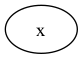

program2 = ['+', 1, 2]


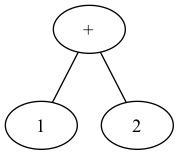

program3 = ['*', ['/', 4, 2], 2]


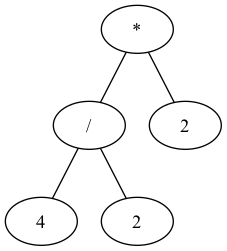

program4 = ['*', 'x', ['+', 1, 2]]


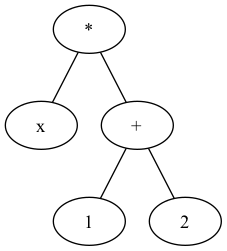

program5 = ['-', ['+', 1, 2], ['+', 1, 2]]


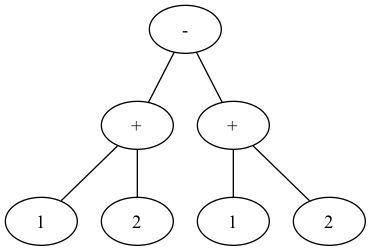

In [3]:
# Task 3

from graphviz import Graph
from IPython.display import display, Image

def visualize_tree(program):
    visual_tree = visualize_tree_aux(program)
    display(Image(visual_tree.pipe(format='png')))

def visualize_tree_aux(tree, graph=None, parent=None, counter=[0]):
    if graph is None:
        graph = Graph(format='png')
    
    node_id = str(counter[0])
    counter[0] += 1
    
    if isinstance(tree, (list, tuple)):
        label = str(tree[0])
        graph.node(node_id, label)
        if parent is not None:
            graph.edge(parent, node_id)
        
        for child in tree[1:]:
            visualize_tree_aux(child, graph, node_id, counter)
    else:
        graph.node(node_id, str(tree))
        if parent is not None:
            graph.edge(parent, node_id)
    
    return graph

# Visualise the programs
for n, program in enumerate([program1, program2, program3, program4, program5]):
    print(f'program{n+1} = {program}')
    visualize_tree(program)

Program: ['*', '3', '2']


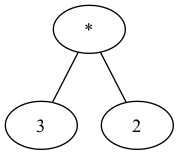

Program: ['+', '3', '1']


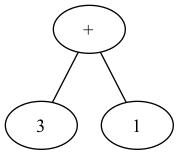

Program: ['/', '2', '1']


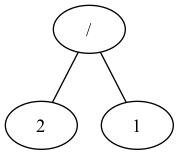

Program: ['+', '2', '2']


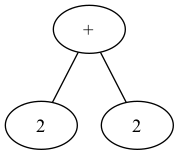

Program: ['+', 'x', '1']


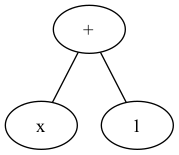

Program: ['-', '2', ['+', '1', '1']]


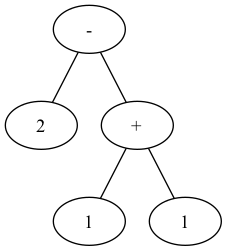

Program: ['+', '1', ['*', '2', '2']]


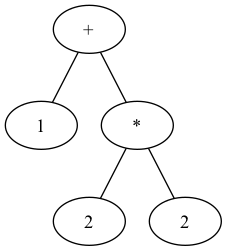

Program: ['*', '3', ['*', '3', 'x']]


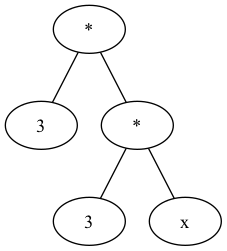

Program: ['+', '3', ['/', '1', '2']]


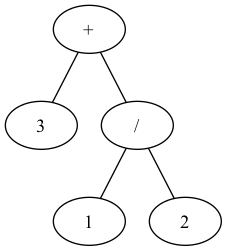

Program: ['*', '3', ['-', '2', '2']]


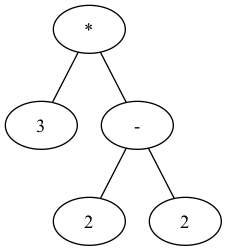

Program: ['*', ['*', '2', '1'], ['/', '2', '2']]


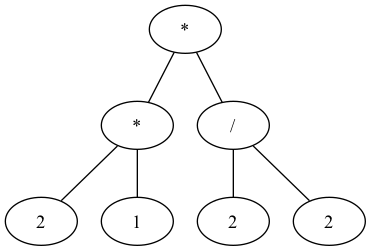

Program: ['/', ['-', '3', '2'], ['-', '3', '2']]


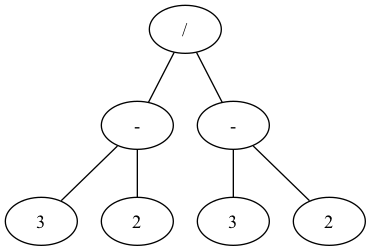

Program: ['/', ['-', '1', '1'], ['+', '1', 'x']]


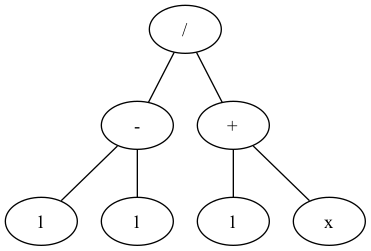

Program: ['*', ['*', '1', 'x'], ['*', 'x', '2']]


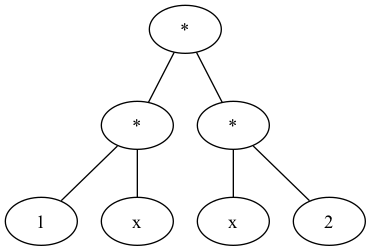

Program: ['+', ['-', '1', '3'], ['-', '1', '3']]


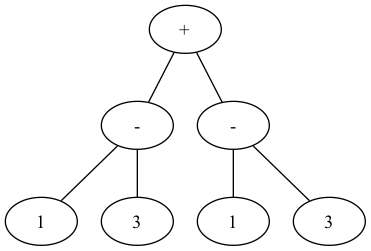

In [4]:
# Task 4
from random import choice

terminals = ['x', '1', '2', '3']
functions = ['*', '+', '-', '/']

def rand_prog2():
    rand_prog = [choice(functions), 
                 choice(terminals), 
                 choice(terminals)]
    return rand_prog
    
# Random programs like program2
for n in range(5):
    rand_prog = rand_prog2()
    print('Program:', rand_prog)
    visualize_tree(rand_prog)


# Random programs like program4

def rand_prog4():
    rand_sub_prog = rand_prog2()
    
    rand_prog = [choice(functions), 
                 choice(terminals), 
                 rand_sub_prog]
    return rand_prog

for n in range(5):
    rand_prog = rand_prog4()
    
    print('Program:', rand_prog)
    visualize_tree(rand_prog)


# Random programs like program5

def rand_prog5():
    rand_sub_prog1 = rand_prog2()
    
    rand_sub_prog2 = rand_prog2()
    
    rand_prog = [choice(functions), 
                 rand_sub_prog1, 
                 rand_sub_prog2]
    return rand_prog
    
for n in range(5):
    rand_prog = rand_prog5()
    print('Program:', rand_prog)
    visualize_tree(rand_prog)


standard end recursion probability
Program: ['+', '3', ['/', '1', ['+', '2', ['+', ['/', ['*', ['+', '3', '2'], '3'], ['+', 'x', ['*', ['*', 'x', '3'], ['/', '3', '3']]]], ['-', ['/', ['*', ['+', ['+', ['-', ['*', ['-', '2', '3'], ['*', ['/', ['-', ['/', '1', '3'], ['*', ['+', '2', ['*', '1', '1']], '3']], ['+', ['/', '2', ['+', '1', ['+', ['*', ['*', '3', ['+', ['+', ['-', ['*', ['/', ['/', '1', '3'], '2'], ['*', 'x', '2']], ['+', ['+', ['+', ['*', ['/', ['+', '3', ['+', ['-', '3', '1'], ['+', ['+', '1', ['/', ['/', '1', '3'], ['/', 'x', ['*', '2', 'x']]]], 'x']]], '3'], '1'], ['/', '3', 'x']], '1'], '1']], ['*', ['*', 'x', '2'], 'x']], ['/', '2', 'x']]], '2'], '2']]], ['+', ['/', ['/', '1', '3'], ['*', '2', '2']], '2']]], ['/', ['/', ['/', ['*', ['-', ['/', '3', 'x'], '1'], '1'], ['-', '2', ['-', ['-', 'x', '3'], 'x']]], ['/', ['-', ['/', '2', '3'], '3'], 'x']], '1']]], ['-', ['/', '1', '2'], '1']], '2'], '2'], '1'], 'x'], 'x']]]]]


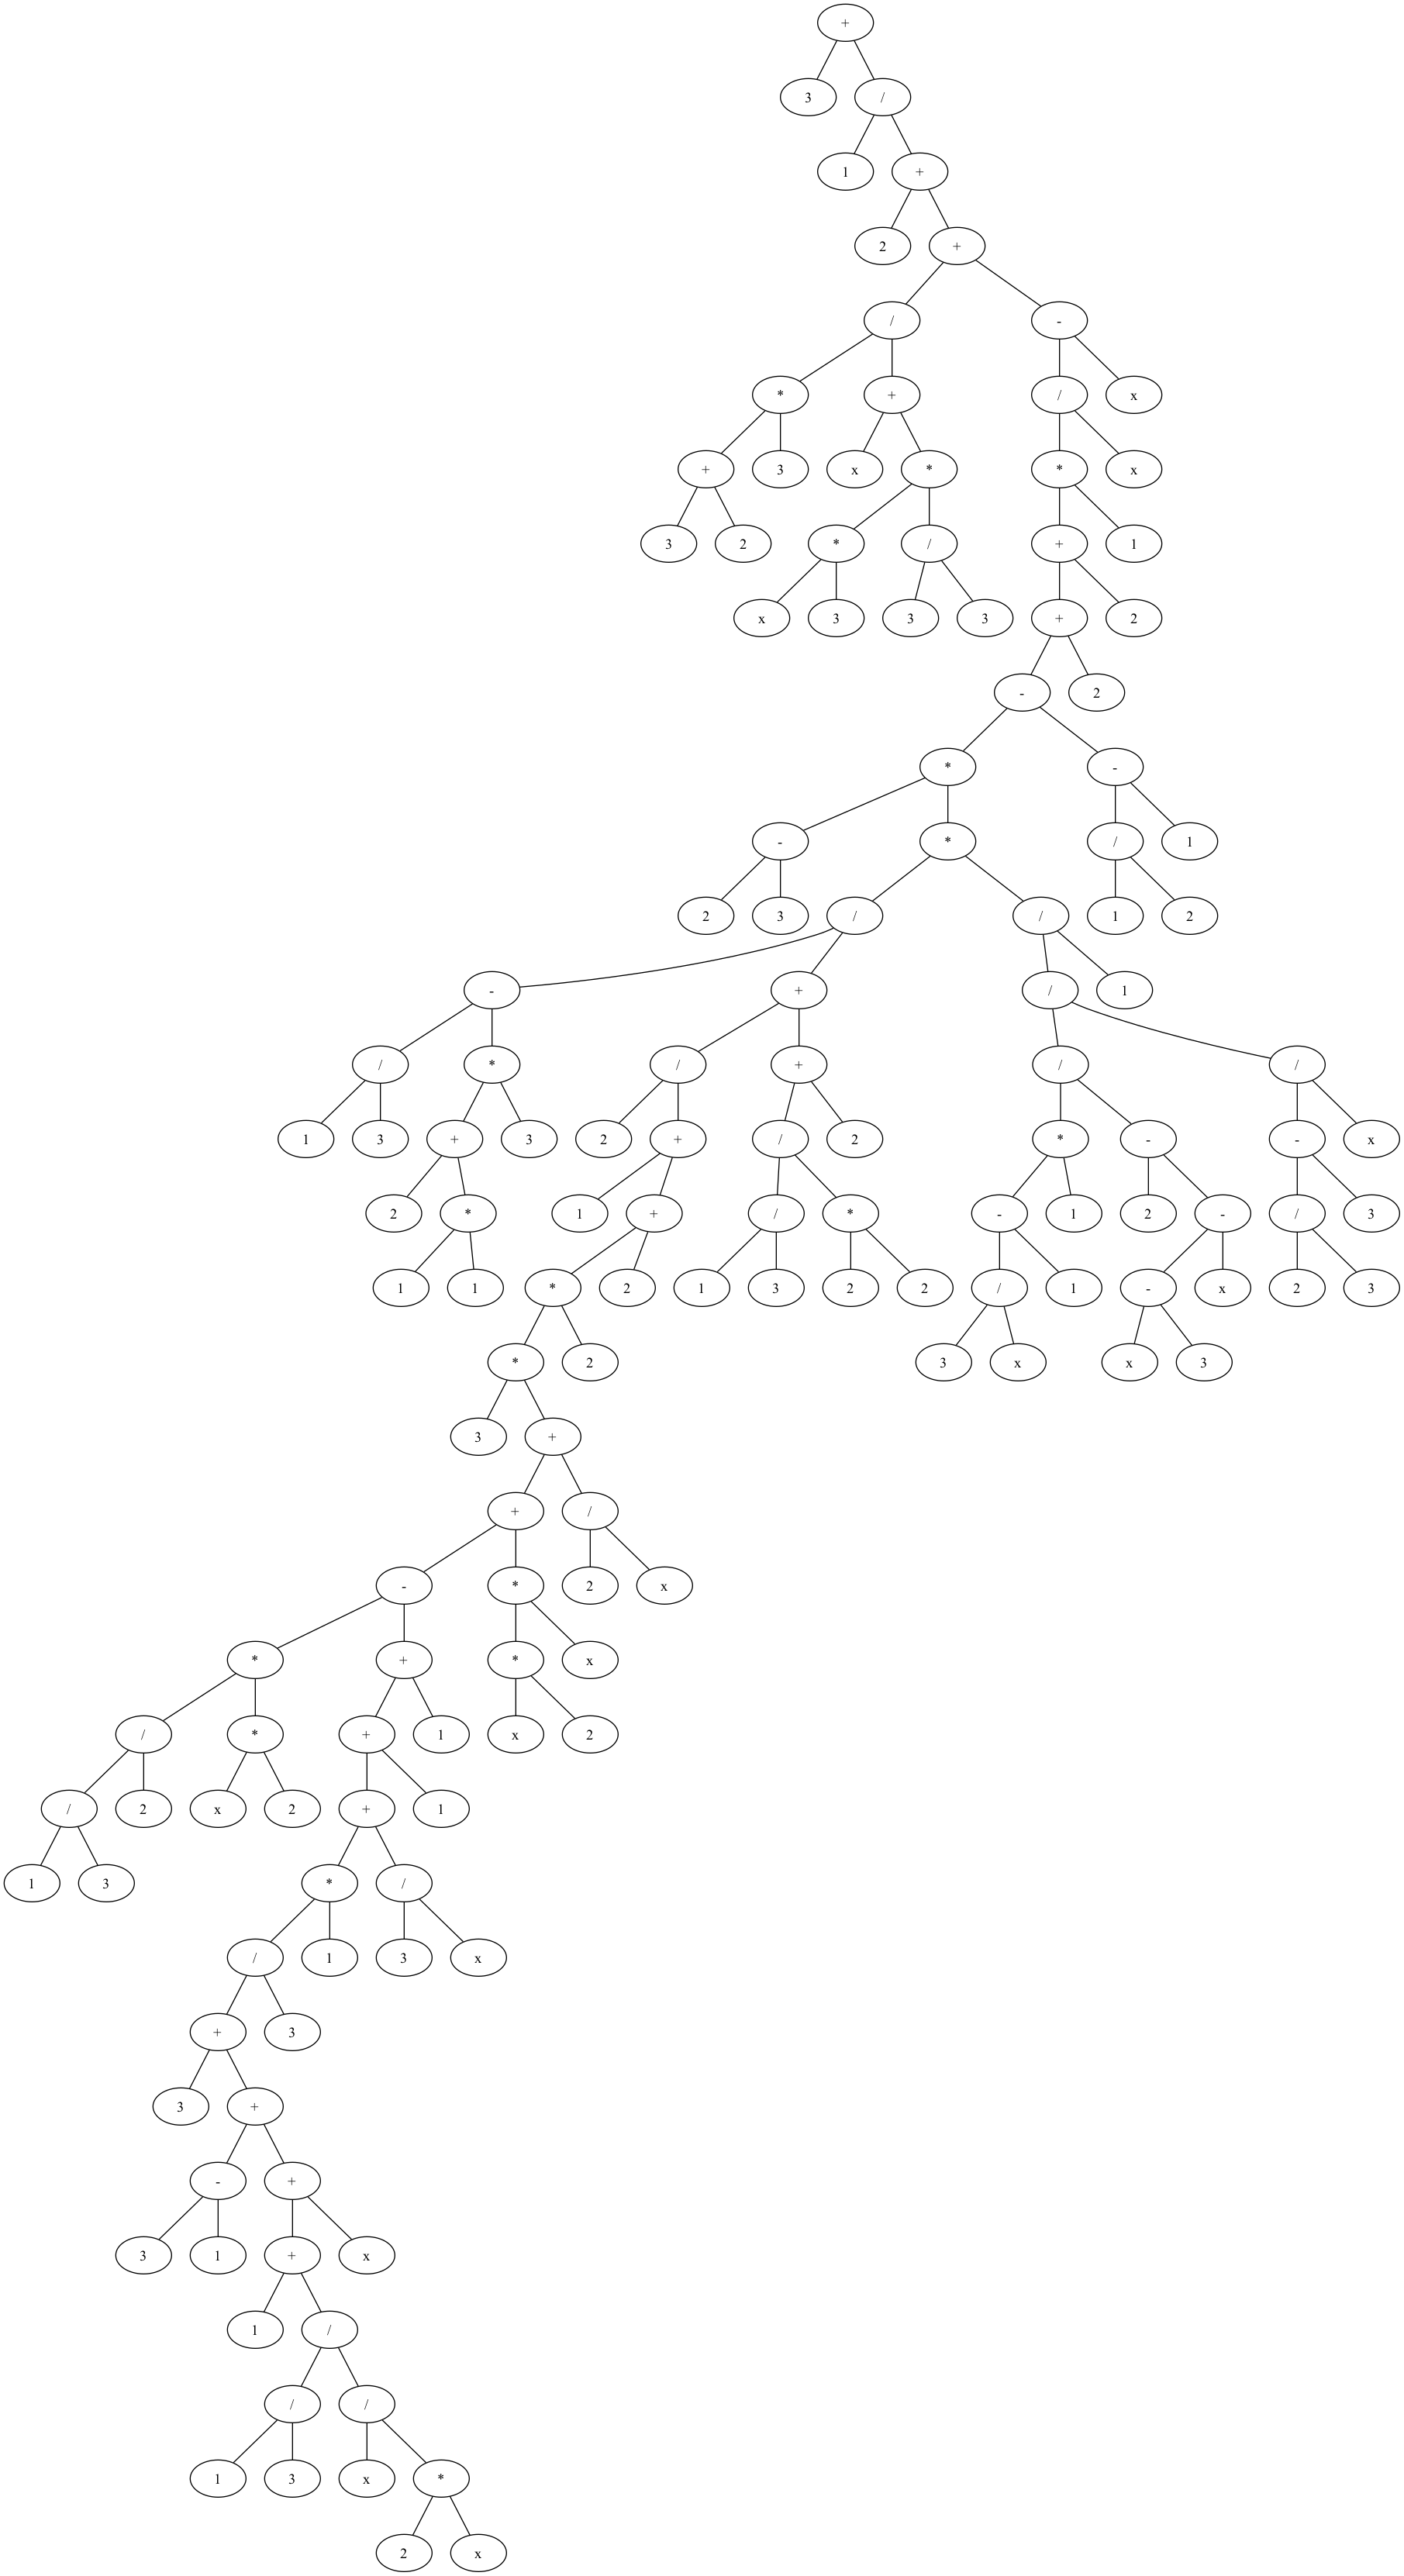

Program: 3


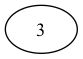

Program: 2


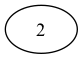

Program: 3


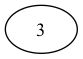

Program: ['*', '3', ['-', ['/', 'x', ['+', ['/', 'x', '1'], ['/', ['+', '3', ['*', ['+', '2', '1'], '3']], ['/', '2', '3']]]], '3']]


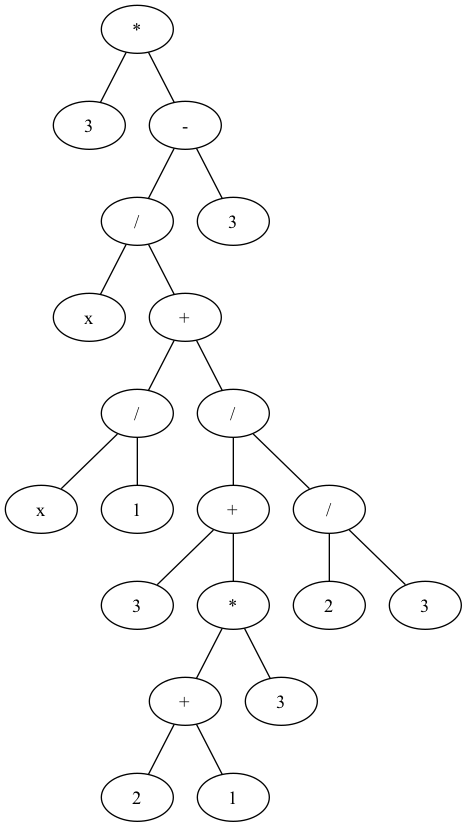

0.7 end recursion probability
Program: x


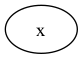

Program: 3


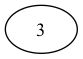

Program: 1


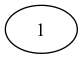

Program: ['+', ['+', 'x', '3'], '2']


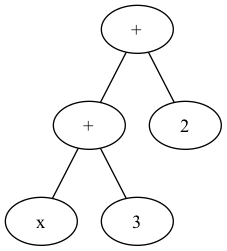

Program: ['+', 'x', '2']


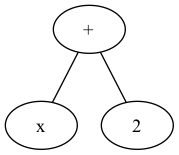

0.3 end recursion probability
Program: 1


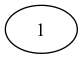

RecursionError: maximum recursion depth exceeded while calling a Python object

In [5]:
# Task 5
from random import random

def generate_random_program(end_recursion_prob = 0.55):
    if random() < end_recursion_prob:
        return choice(terminals)
    else:
        return [choice(functions), 
                 generate_random_program(end_recursion_prob=end_recursion_prob), 
                 generate_random_program(end_recursion_prob=end_recursion_prob)]

# Testing
print('standard end recursion probability')
for n in range(5):
    rand_prog = generate_random_program()
    print('Program:', rand_prog)
    visualize_tree(rand_prog)

# Testing
print('0.7 end recursion probability')
for n in range(5):
    rand_prog = generate_random_program(end_recursion_prob=0.7)
    print('Program:', rand_prog)
    visualize_tree(rand_prog)

# Testing
print('0.3 end recursion probability')
# Expected to fail due to infinite recursion.....
for n in range(5):
    rand_prog = generate_random_program(end_recursion_prob=0.3)
    print('Program:', rand_prog)
    visualize_tree(rand_prog)

================================ Full ================================
Program: ['/', ['/', ['+', 'x', '3'], ['+', '3', 'x']], ['-', ['-', '3', '2'], ['+', '1', '3']]]


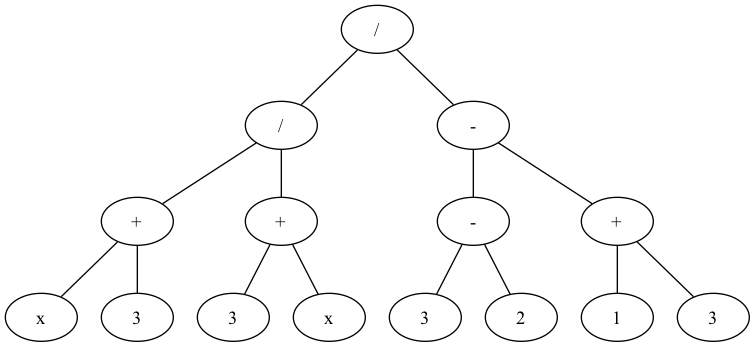

Program: ['+', ['*', ['+', '3', '3'], ['+', 'x', '3']], ['*', ['*', '1', '2'], ['-', '1', '2']]]


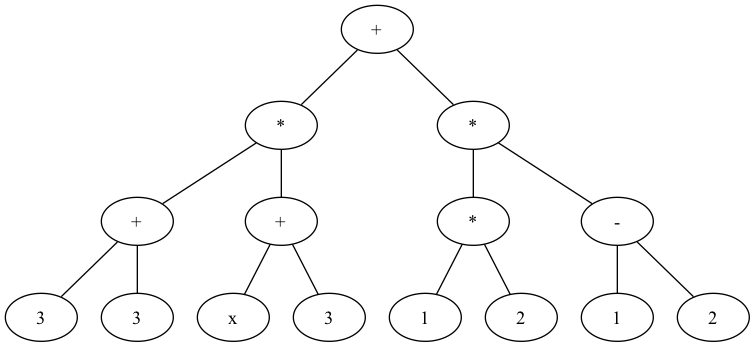

Program: ['*', ['+', ['-', 'x', '1'], ['-', '1', '2']], ['/', ['*', '1', '1'], ['+', 'x', 'x']]]


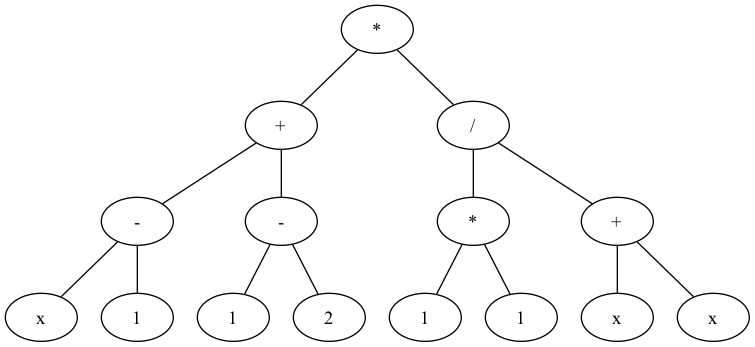

Program: ['-', ['-', ['/', '1', '2'], ['-', '3', '3']], ['-', ['-', 'x', '2'], ['/', '3', 'x']]]


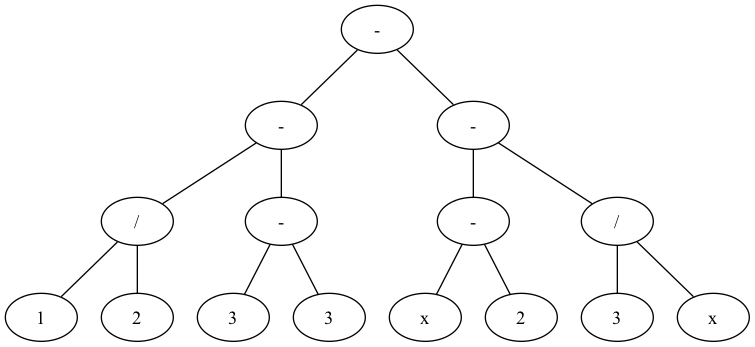

Program: ['+', ['+', ['*', '2', '1'], ['+', '3', '1']], ['+', ['-', '3', '3'], ['+', '2', '2']]]


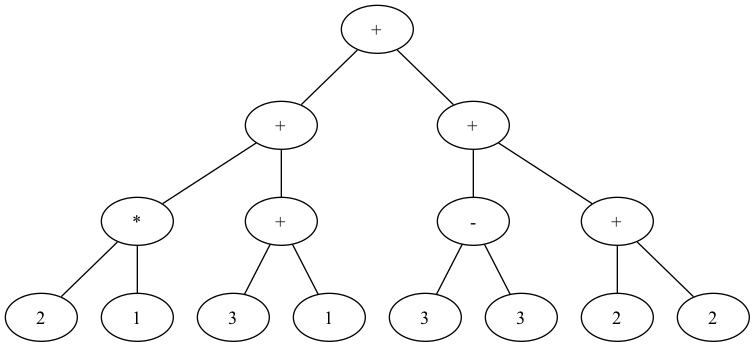

================================ Grow ================================
Program: ['+', ['*', '1', ['/', '1', '2']], ['*', ['-', '2', 'x'], ['+', '3', 'x']]]


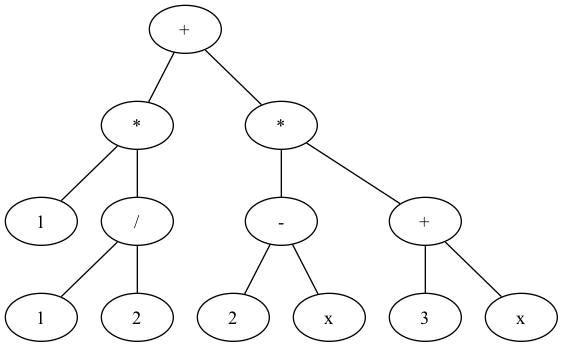

Program: 1


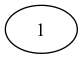

Program: 3


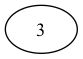

Program: ['-', '3', ['*', ['-', 'x', '3'], '2']]


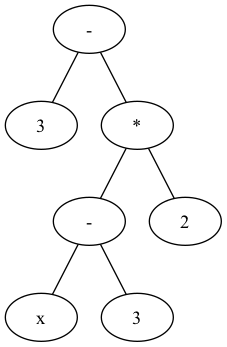

Program: x


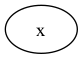

In [11]:
# Task 6

from random import choice, random

def full(maxD):
    # At max depth, pick a terminal
    if maxD == 0:
        return choice(terminals)
    else:
        # Pick a function and fill its arguments
        func = choice(functions)
        expr = [func]
        for _ in range(2):
            expr.append(full(maxD - 1))
        return expr

prob_term = len(terminals) / (len(terminals) + len(functions))

def grow(maxD):
    # At max depth OR randomly decided to insert a terminal
    if maxD == 0 or random() < prob_term:
        return choice(terminals)
    else:
        # Pick a function and fill its arguments
        func = choice(functions)
        expr = [func]
        for _ in range(2):
            expr.append(grow(maxD - 1))
        return expr

# Testing
max_depth = 3
print('================================ Full ================================')
for n in range(5):
    rand_prog = full(max_depth)
    print('Program:', rand_prog)
    visualize_tree(rand_prog)

max_depth = 3
print('================================ Grow ================================')
for n in range(5):
    rand_prog = grow(max_depth)
    print('Program:', rand_prog)
    visualize_tree(rand_prog)


================================ Full ================================
Program: ['cos', ['sin', ['sin', '1']]]


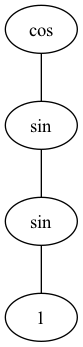

Program: ['cos', ['cos', ['cos', 'x']]]


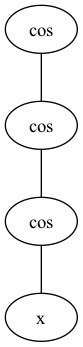

Program: ['+', ['-', ['sin', '0'], ['-', '1', 'x']], ['-', ['*', '1', '1'], ['+', '1', '0']]]


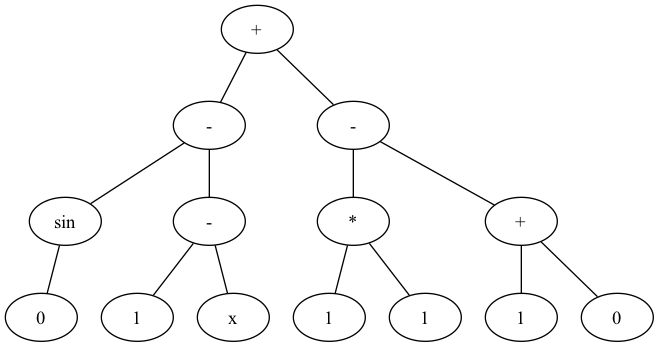

Program: ['sin', ['*', ['*', 'x', '0'], ['*', 'x', '0']]]


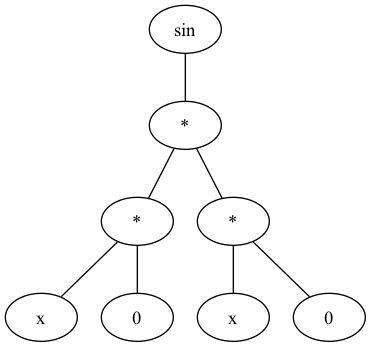

Program: ['sin', ['*', ['+', '1', '1'], ['cos', '0']]]


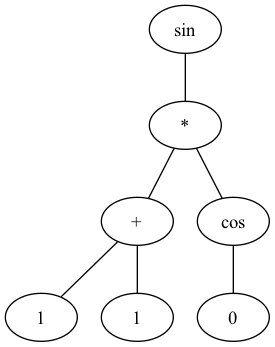

================================ Grow ================================
Program: ['+', 'x', ['*', '1', '1']]


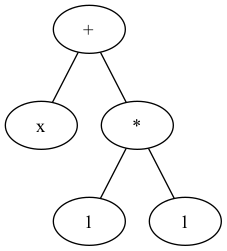

Program: ['sin', ['+', ['cos', 'x'], ['+', 'x', '0']]]


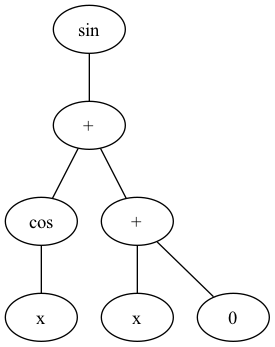

Program: 1


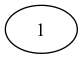

Program: ['*', 'x', '1']


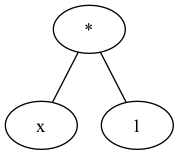

Program: x


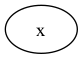

In [12]:
# Task 7

# New primitives representation
functions = [['sin', 1], ['cos', 1], # Format: [Name, Arity]
            ['+', 2], ['-', 2], ['*', 2]] 

terminals = ['x', '1', '0'] # Format: Name

from random import choice, random

def full(maxD):
    # At max depth, pick a terminal
    if maxD == 0:
        return choice(terminals)
    else:
        # Pick a function and fill its arguments
        func, arity = choice(functions)
        expr = [func]
        for _ in range(arity):
            expr.append(full(maxD - 1))
        return expr

prob_term = len(terminals) / (len(terminals) + len(functions))

def grow(maxD):
    # At max depth OR randomly decided to insert a terminal
    if maxD == 0 or random() < prob_term:
        return choice(terminals)
    else:
        # Pick a function and fill its arguments
        func, arity = choice(functions)
        expr = [func]
        for _ in range(arity):
            expr.append(grow(maxD - 1))
        return expr

# Testing
max_depth = 3
print('================================ Full ================================')
for n in range(5):
    rand_prog = full(max_depth)
    print('Program:', rand_prog)
    visualize_tree(rand_prog)

max_depth = 3
print('================================ Grow ================================')
for n in range(5):
    rand_prog = grow(max_depth)
    print('Program:', rand_prog)
    visualize_tree(rand_prog)



generate_random_program() called
  generate_random_program() called
  generate_random_program() returned 2
  generate_random_program() called
  generate_random_program() returned x
generate_random_program() returned ['*', '2', 'x']
Program: ['*', '2', 'x']


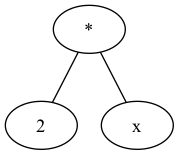

In [9]:
# Task 8
import functools

def trace(func):
    @functools.wraps(func)
    def wrapper(*args):
        wrapper.depth += 1
        indent = "  " * wrapper.depth
        print(f"{indent}{func.__name__}{args} called")

        result = func(*args)

        print(f"{indent}{func.__name__}{args} returned {result}")
        wrapper.depth -= 1
        return result
    
    wrapper.depth = -1
    wrapper.original = func  
    return wrapper

@trace            
def generate_random_program():
    if random() < 0.55:
        return choice(terminals)
    else:
        return [choice(functions), 
                 generate_random_program(), 
                 generate_random_program()]

# Testing
rand_prog = generate_random_program()

print('Program:', rand_prog)
visualize_tree(rand_prog)

# Untracing generate_random_program()
generate_random_program = generate_random_program.original 